## Simulating observations with MUSTANG-2

MUSTANG-2 is a bolometric array on the [Green Bank Telescope](https://en.wikipedia.org/wiki/Green_Bank_Telescope). In this notebook we simulate an observation of the Crab Nebula (M1).

ProjectionMap:
  data(1, 251, 251):
    min: 3.723e+03
    max: 1.005e+06
    units: uK_RJ
    quantity: rayleigh_jeans_temperature
  nu(1):
    values: [150.] GHz
  eta(251):
    height: 9’
    res: -2.16”
  xi(251): 
    width: 9’
    res: 2.16”
  frame: ra/dec
  center:
    ra: 05ʰ38ᵐ44.48ˢ
    dec: -69°06’12.81”
  beam(maj, min, psi): (0 rad, 0 rad, 0 rad)
  memory: 252 kB


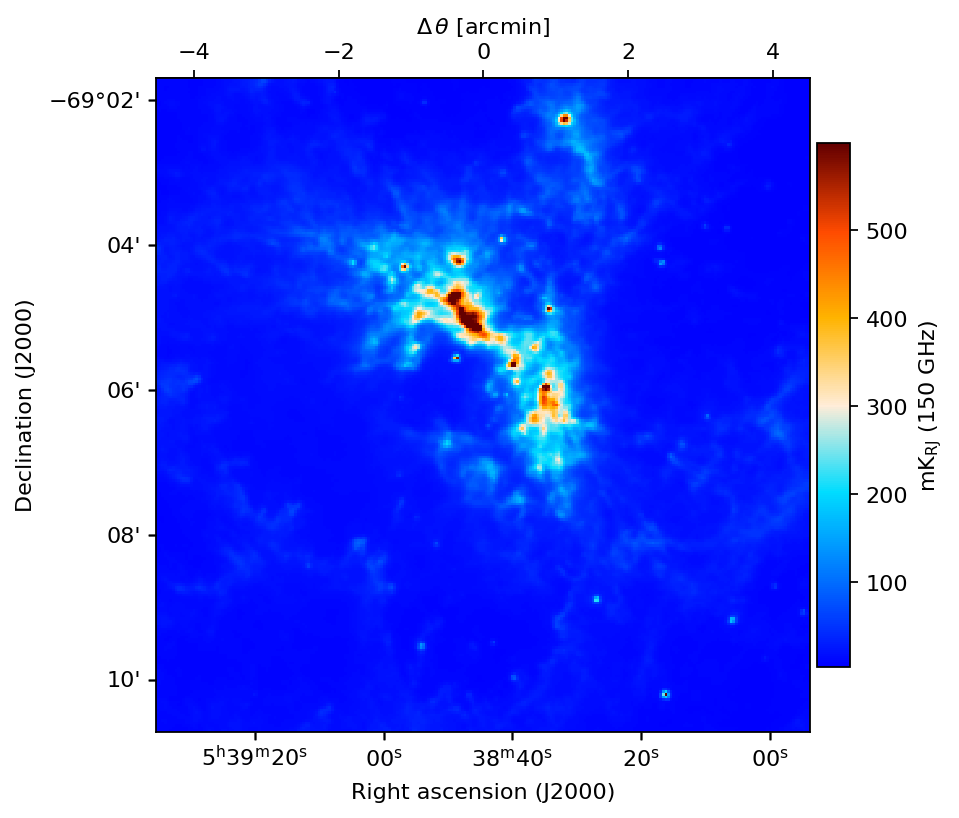

In [1]:
import maria

input_map = maria.map.get("maps/30dor.fits", nu=150e9).to("uK_RJ")

input_map.plot()
print(input_map)

PlanList(1 plans, 300 s):
                           start_time duration    target(ra,dec)     center(az,el)
chunk                                                                             
0      2026-06-05 15:04:36.107 +00:00    300 s  (84.69°, -69.1°)  (165.9°, 40.15°)


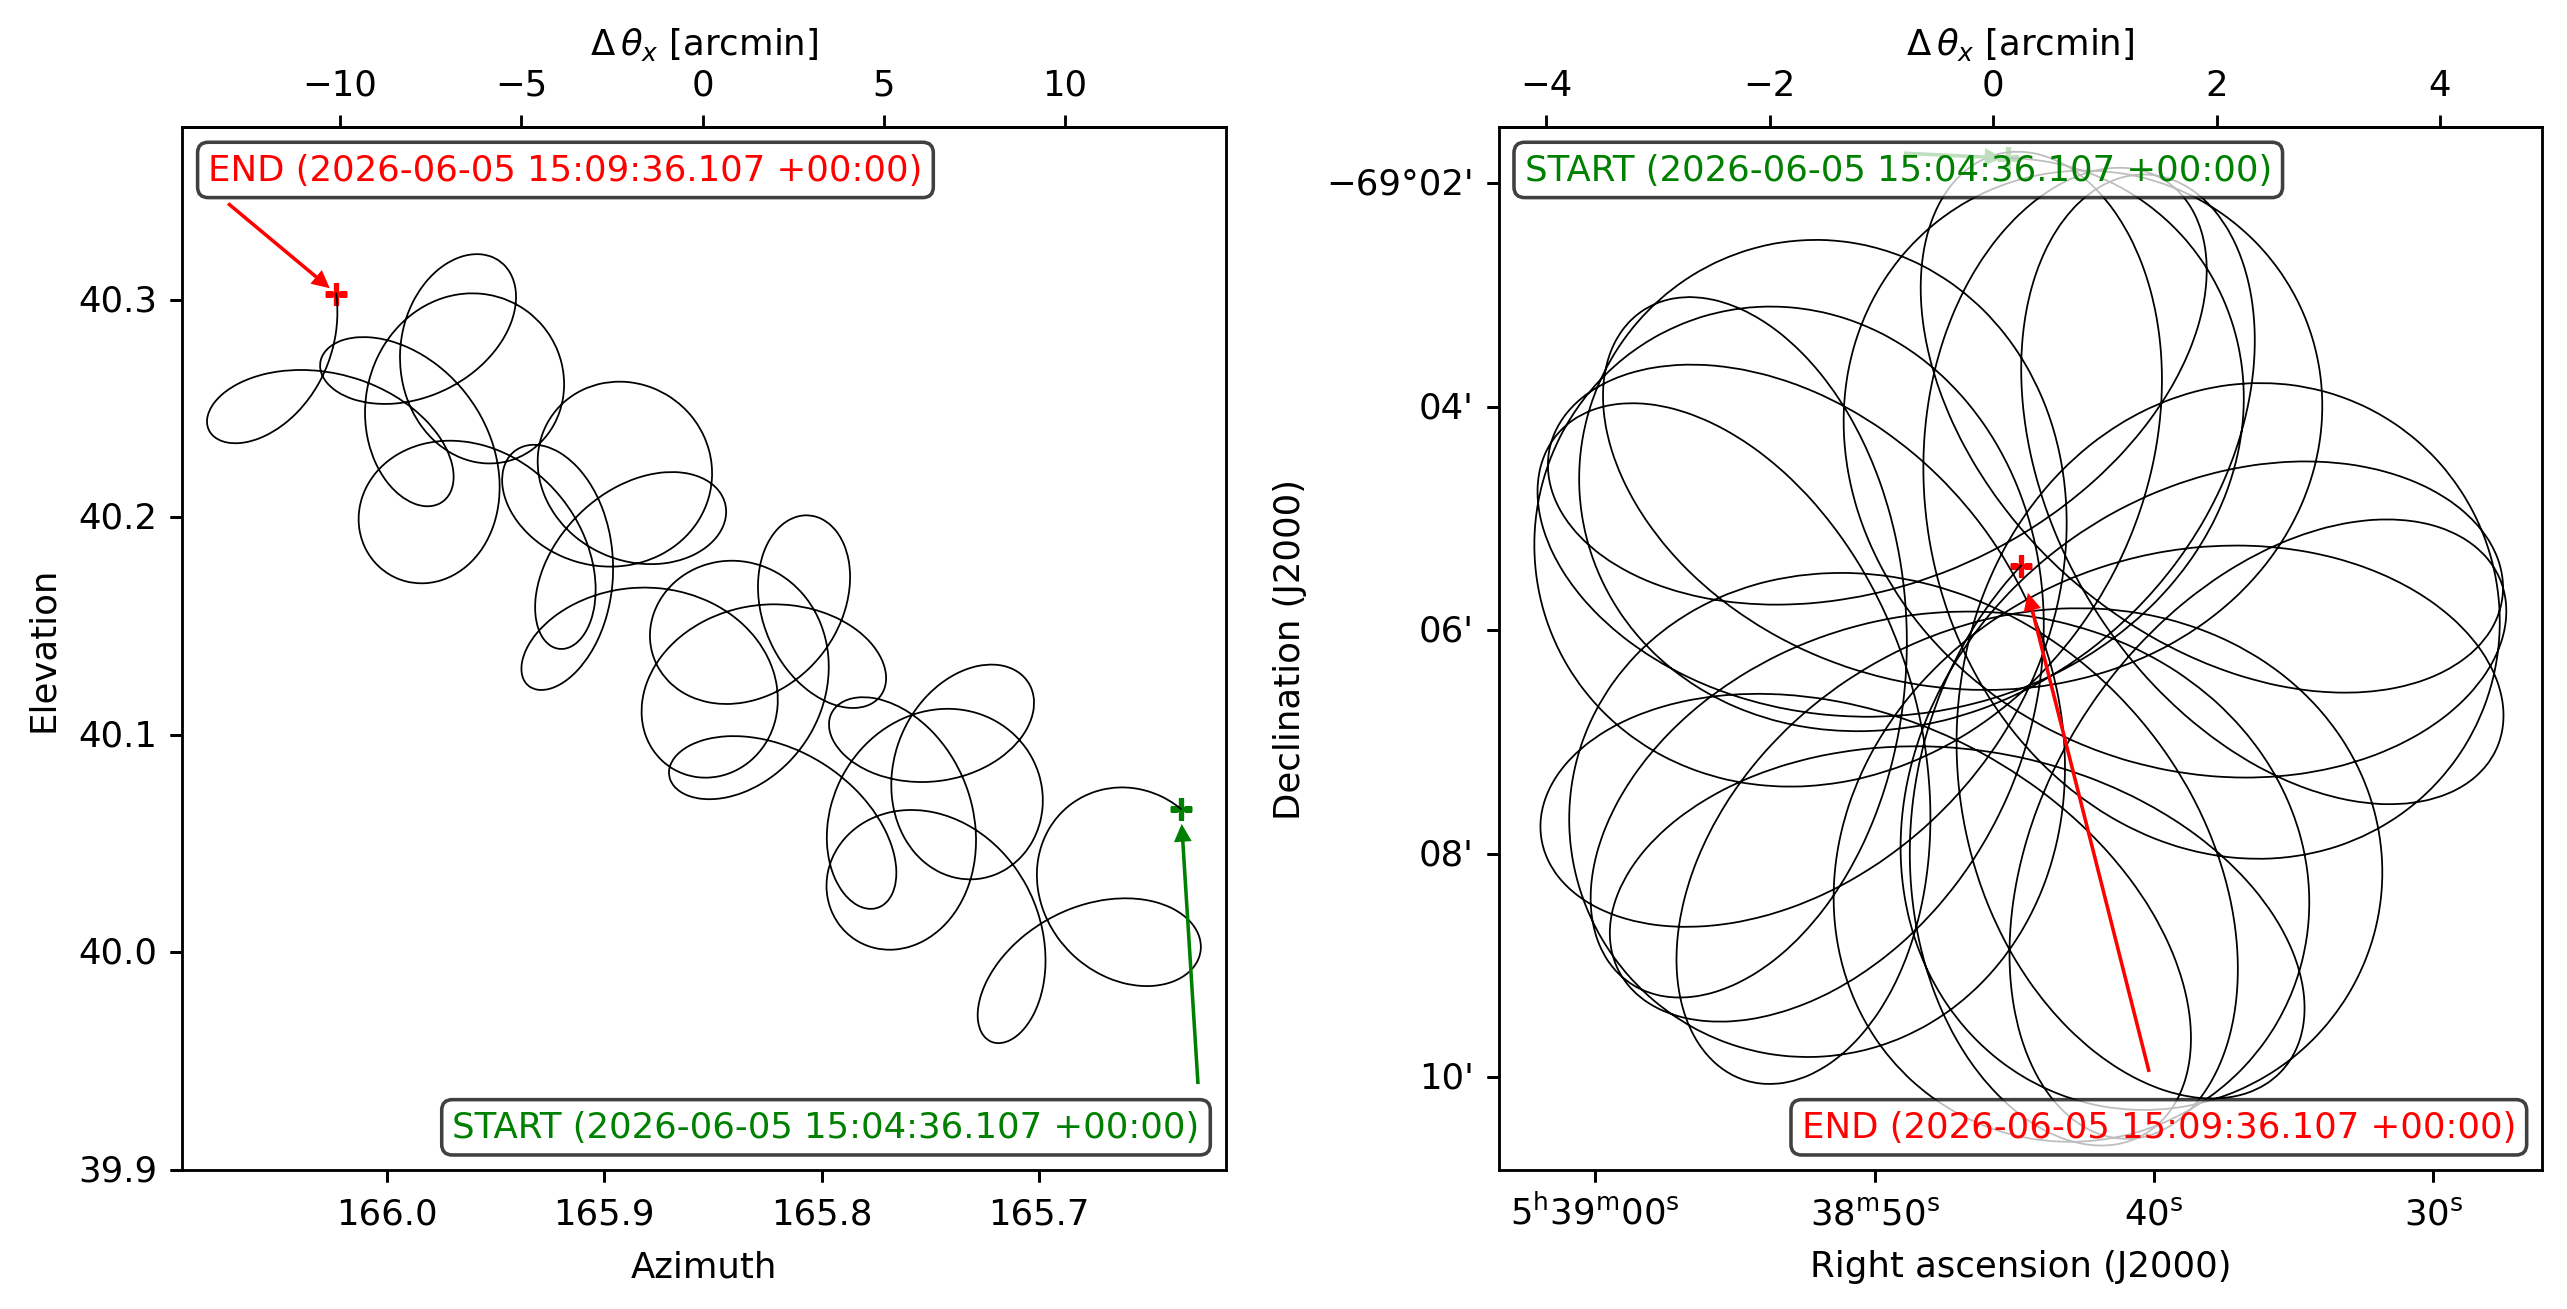

In [2]:
from maria import Planner

planner = Planner(target=input_map, site="cerro_chajnantor", constraints={"el": (40, 90)})
plans = planner.generate_plans(total_duration=300, sample_rate=50)

plans[0].plot()
print(plans)

Instrument(1 array)
├ arrays:
│                   n field_of_view max_baseline         bands polarized primary_size
│  apex/artemis  2304        5.274’          0 m  [apex/350um]     False         12 m
│ 
└ bands:
            name   center    width    η         NEP      NET_RJ        NET_CMB    FWHM
   0  apex/350um  852 GHz  120 GHz  0.5  17.63 fW√s  20 mK_RJ√s  217.1 K_CMB√s  7.701”


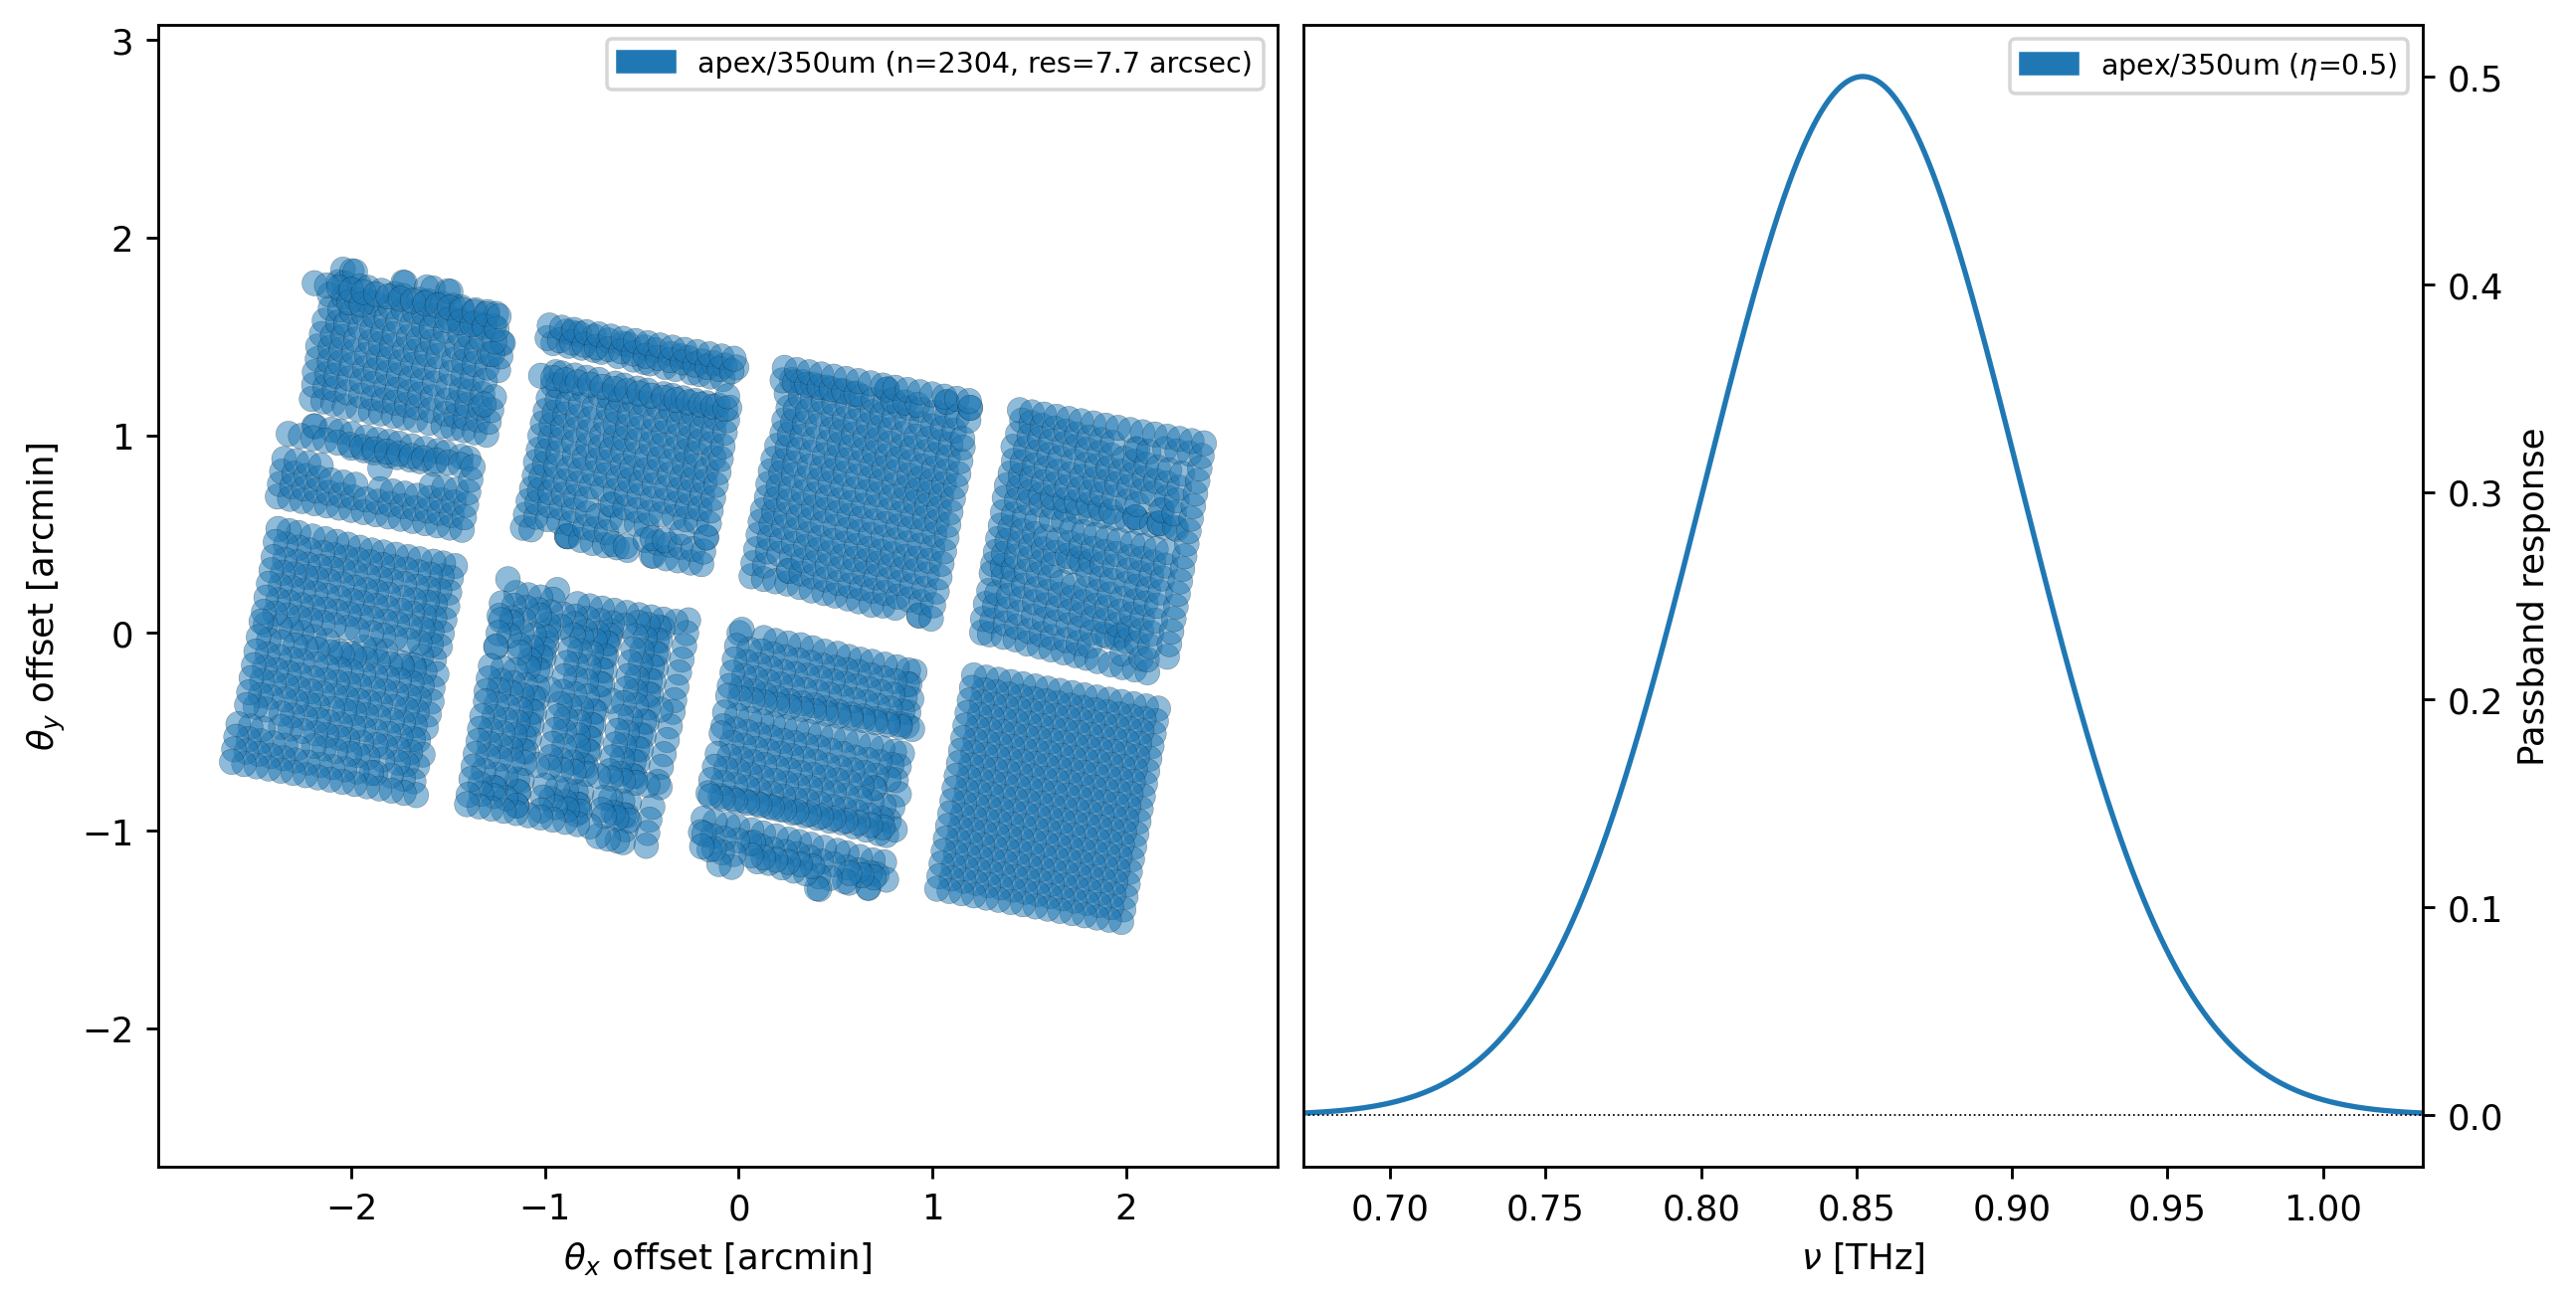

In [3]:
instrument = maria.get_instrument("apex/artemis")

print(instrument)
instrument.plot()

In [4]:
sim = maria.Simulation(
    instrument,
    plans=plans,
    site="cerro_chajnantor",
    map=input_map,
    atmosphere="2d",
    atmosphere_kwargs={"weather": {"pwv": 0.25}},
)

print(sim)

Constructing atmosphere:   0%|          | 0/8 [00:00<?, ?it/s]

Constructing atmosphere:  12%|█▎        | 1/8 [00:00<00:05,  1.18it/s]

Constructing atmosphere:  25%|██▌       | 2/8 [00:01<00:05,  1.13it/s]

Constructing atmosphere:  38%|███▊      | 3/8 [00:02<00:04,  1.15it/s]

Constructing atmosphere:  50%|█████     | 4/8 [00:03<00:03,  1.10it/s]

...

Constructing atmosphere:  75%|███████▌  | 6/8 [00:05<00:01,  1.21it/s]

Constructing atmosphere:  88%|████████▊ | 7/8 [00:05<00:00,  1.19it/s]

Constructing atmosphere: 100%|██████████| 8/8 [00:06<00:00,  1.20it/s]

Constructing atmosphere: 100%|██████████| 8/8 [00:06<00:00,  1.18it/s]

Simulation
├ Instrument(1 array)
│ ├ arrays:
│ │                   n field_of_view max_baseline         bands polarized primary_size
│ │  apex/artemis  2304        5.274’          0 m  [apex/350um]     False         12 m
│ │ 
│ └ bands:
│             name   center    width    η         NEP      NET_RJ        NET_CMB    FWHM
│    0  apex/350um  852 GHz  120 GHz  0.5  17.63 fW√s  20 mK_RJ√s  217.1 K_CMB√s  7.701”
├ Site:
│   region: chajnantor
│   timezone: America/Santiago
│   location:
│     longitude: 67°44’31.92” W
│     latitude:  22°59’10.32” S
│     altitude: 5.6 km
│   seasonal: True
│   diurnal: True
├ PlanList(1 plans, 300 s):
│                            start_time duration    target(ra,dec)     center(az,el)
│ chunk                                                                             
│ 0      2026-06-05 15:04:36.107 +00:00    300 s  (84.69°, -69.1°)  (165.9°, 40.15°)
├ Atmosphere(8 processes with 8 layers):
│ ├ spectrum:
│ │   region: chajnantor
│ └ weather:
│     reg

2026-06-05 11:36:07.768 INFO: Simulating observation 1 of 1


Generating turbulence:   0%|          | 0/8 [00:00<?, ?it/s]

Generating turbulence:  38%|███▊      | 3/8 [00:00<00:00, 20.31it/s]

Generating turbulence:  75%|███████▌  | 6/8 [00:00<00:00, 15.52it/s]

Generating turbulence: 100%|██████████| 8/8 [00:00<00:00, 12.48it/s]

...

Generating noise:   0%|          | 0/1 [00:00<?, ?it/s]

Generating noise:   0%|          | 0/1 [00:00<?, ?it/s, band=apex/350um]

Generating noise: 100%|██████████| 1/1 [00:02<00:00,  2.54s/it, band=apex/350um]

Generating noise: 100%|██████████| 1/1 [00:02<00:00,  2.54s/it, band=apex/350um]

2026-06-05 11:36:53.132 INFO: Simulated observation 1 of 1 in 45.35 s


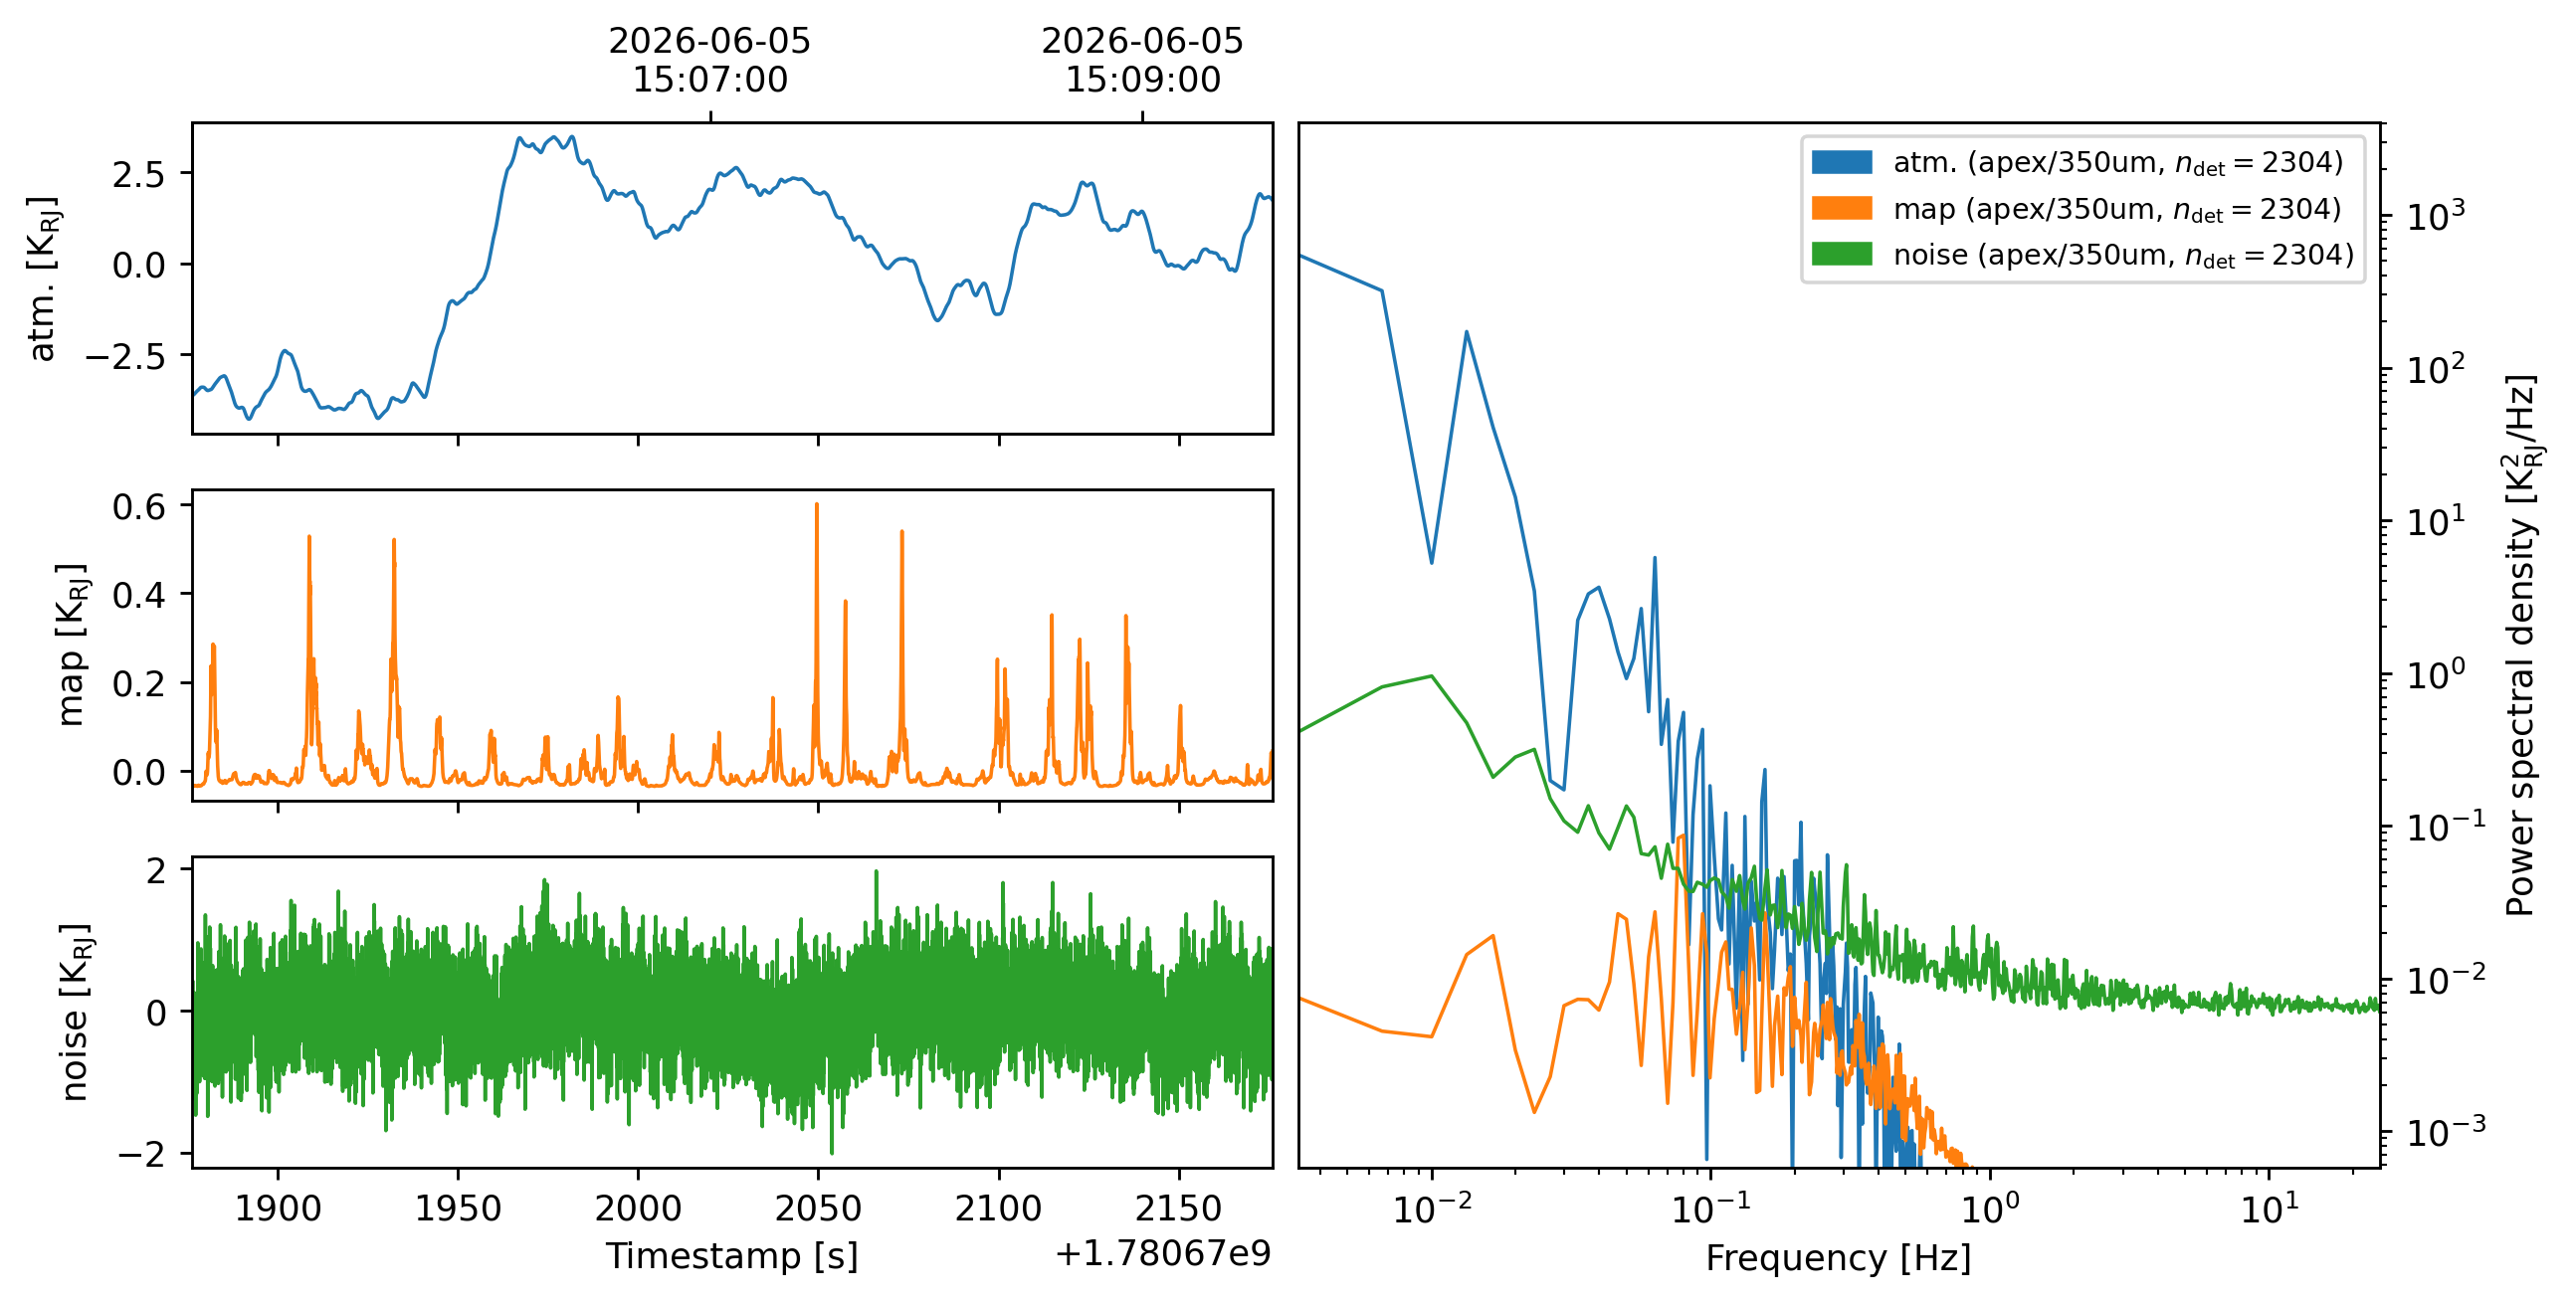

In [5]:
tods = sim.run()
tods[0].plot()

2026-06-05 11:36:58.572 INFO: Inferring resolution = 3.85” from detector FWHM


2026-06-05 11:37:02.773 INFO: Inferring center {'ra': '05ʰ38ᵐ43.70ˢ', 'dec': '-69°06’12.64”'} for mapper


2026-06-05 11:37:02.785 INFO: Inferring mapper width 14.39’ for mapper from observation patch


2026-06-05 11:37:02.786 INFO: Inferring mapper height 14.39’ to match supplied width


Preprocessing TODs:   0%|          | 0/1 [00:00<?, ?it/s]

Preprocessing TODs: 100%|██████████| 1/1 [00:12<00:00, 12.18s/it]

Preprocessing TODs: 100%|██████████| 1/1 [00:12<00:00, 12.18s/it]

Computing pointing matrices:   0%|          | 0/1 [00:00<?, ?it/s]

Computing pointing matrices: 100%|██████████| 1/1 [00:06<00:00,  6.55s/it]

Computing pointing matrices: 100%|██████████| 1/1 [00:06<00:00,  6.55s/it]

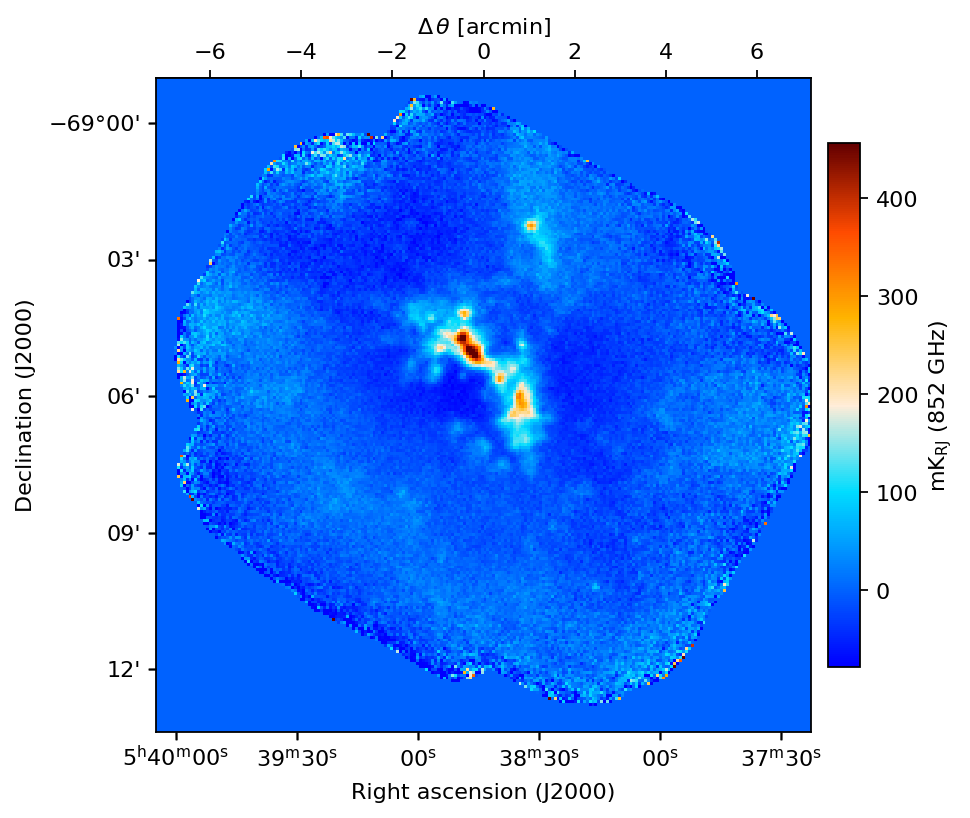

In [6]:
from maria.mappers import MaximumLikelihoodMapper

mapper = MaximumLikelihoodMapper(
    stokes="I",
    tod_preprocessing={
        "remove_spline": {"knot_spacing": 60, "remove_el_gradient_order": 1},
    },
    tods=tods,
)

mapper.map.plot()

Updating noise model:   0%|          | 0/1 [00:00<?, ?it/s]

Updating noise model:   0%|          | 0/1 [00:00<?, ?it/s, tod=1/1]

Updating noise model: 100%|██████████| 1/1 [00:07<00:00,  7.79s/it, tod=1/1]

Updating noise model: 100%|██████████| 1/1 [00:07<00:00,  7.79s/it, tod=1/1]

Fitting map (epoch 1/2): 0it [00:00, ?it/s]

...

Fitting map (epoch 1/2): 316it [27:51,  5.41s/it, alpha=1.97]

Fitting map (epoch 1/2): 317it [27:57,  5.41s/it, alpha=1.97]

Fitting map (epoch 1/2): 317it [27:57,  5.41s/it, alpha=1.1] 

2026-06-05 12:05:51.210 INFO: Finished conjugate gradient descent, terminating


Fitting map (epoch 1/2): 317it [28:02,  5.31s/it, alpha=1.1]

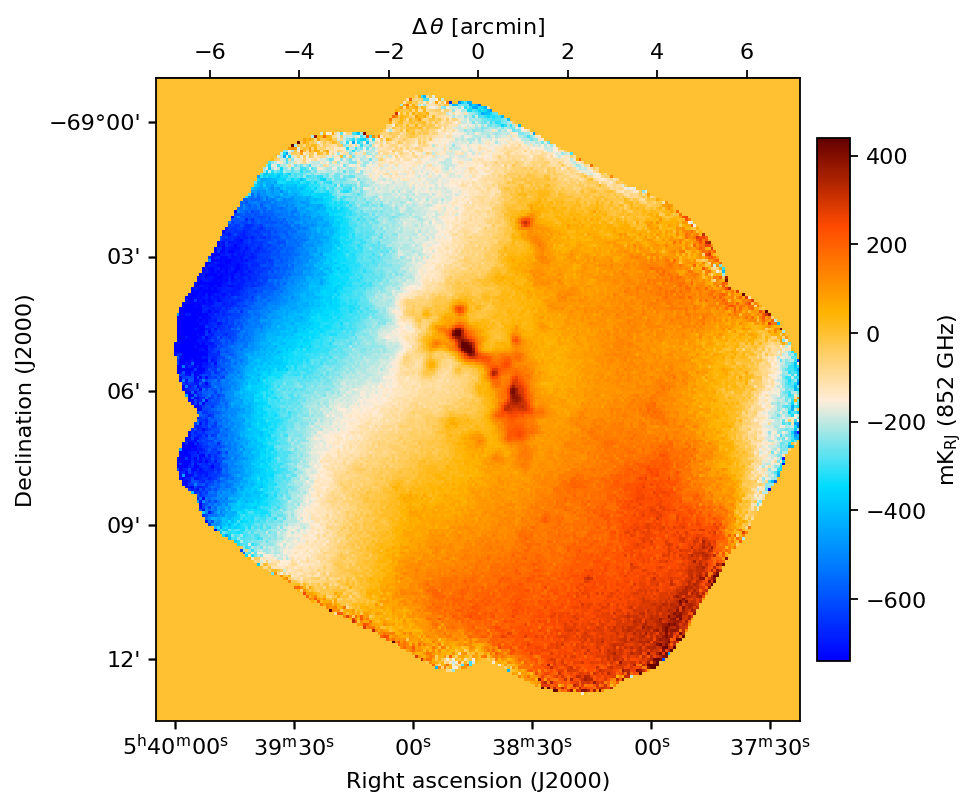

Updating noise model:   0%|          | 0/1 [00:00<?, ?it/s]

Updating noise model:   0%|          | 0/1 [00:00<?, ?it/s, tod=1/1]

Updating noise model: 100%|██████████| 1/1 [00:08<00:00,  8.57s/it, tod=1/1]

Updating noise model: 100%|██████████| 1/1 [00:08<00:00,  8.57s/it, tod=1/1]

Fitting map (epoch 2/2): 0it [00:00, ?it/s]

...

Fitting map (epoch 2/2): 226it [19:50,  5.34s/it, alpha=1.96]

Fitting map (epoch 2/2): 227it [19:55,  5.34s/it, alpha=1.96]

Fitting map (epoch 2/2): 227it [19:55,  5.34s/it, alpha=1.15]

2026-06-05 12:26:02.122 INFO: Finished conjugate gradient descent, terminating


Fitting map (epoch 2/2): 227it [20:01,  5.29s/it, alpha=1.15]

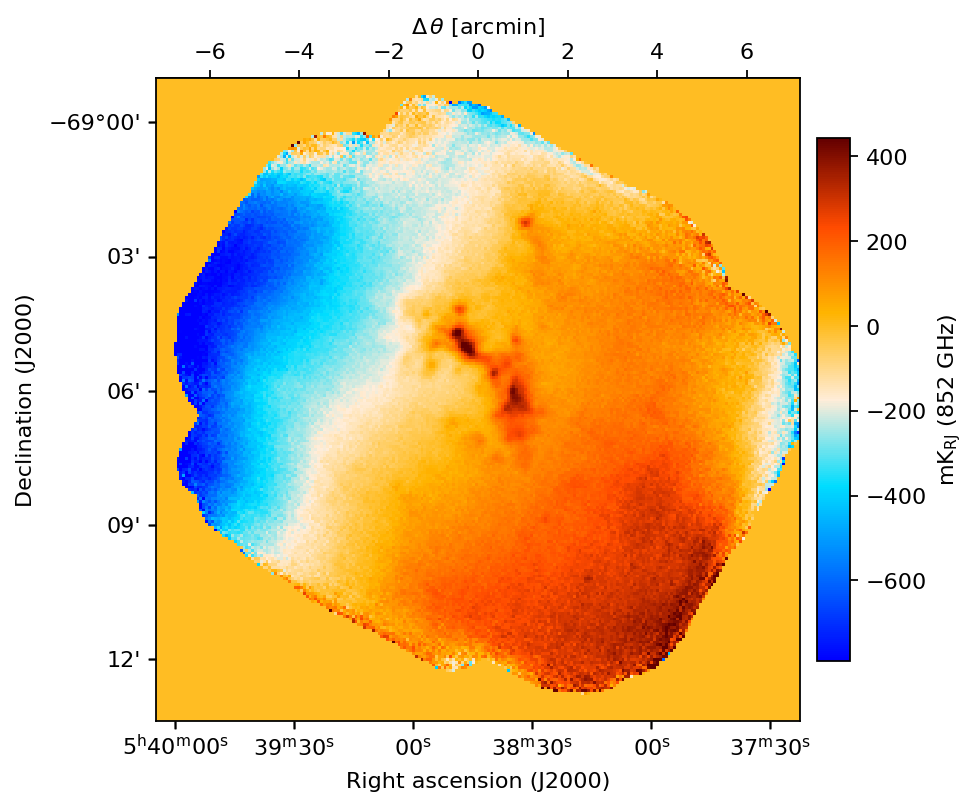

In [7]:
mapper.fit(epochs=2, steps_per_epoch=25, plot=True)